# Supplementary — force prediction (task-space and combined-space)

Estimated vs measured fingertip force for task-space VMC and combined-space VMC
across random stiffness configurations.

In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use(os.path.join('..', 'plot_config.mplstyle'))

OUTPUT_DIR = os.path.join('outputs', 'sensing_task_space_random')

csv_files = []
for cfg in ['task_space', 'combined_space']:
    pattern = os.path.join(OUTPUT_DIR, f'sensing_task_space_random_{cfg}_run_*.csv')
    csv_files += sorted(glob(pattern))
csv_files = [f for f in csv_files if os.path.getsize(f) > 0]
assert csv_files, f'No non-empty CSV files found in {OUTPUT_DIR}'

frames = []
for f in csv_files:
    df = pd.read_csv(f)
    df['SourceFile'] = os.path.basename(f)
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True)
df_all = df_all.drop_duplicates(subset=['Config', 'Sample_Num'], keep='last').reset_index(drop=True)
print(f'Loaded {len(csv_files)} run file(s), {len(df_all)} rows')

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

def metrics(df):
    y = df['Force_Normal_Mean_N'].values
    yp = df['Force_Pred_Mean_N'].values
    rmse = float(np.sqrt(np.mean((y - yp) ** 2)))
    mae = float(np.mean(np.abs(y - yp)))
    sst = np.sum((y - np.mean(y)) ** 2)
    r2 = float(1.0 - np.sum((y - yp) ** 2) / sst) if sst > 0 else np.nan
    return rmse, mae, r2

for cfg in ['task_space', 'combined_space']:
    d = df_all[df_all['Config'] == cfg]
    if len(d) == 0:
        print(f'{cfg:14s}  no data')
        continue
    rmse, mae, r2 = metrics(d)
    print(f'{cfg:14s}  RMSE={rmse:.4f} N  MAE={mae:.4f} N  R2={r2:.4f}')

Loaded 2 run file(s), 80 rows
task_space      RMSE=0.1073 N  MAE=0.0938 N  R2=0.6744
combined_space  RMSE=0.1185 N  MAE=0.1049 N  R2=0.5562


## Scatter — measured vs predicted (per config)

task_space — measured vs predicted normal force (scatter, R² = 0.674)


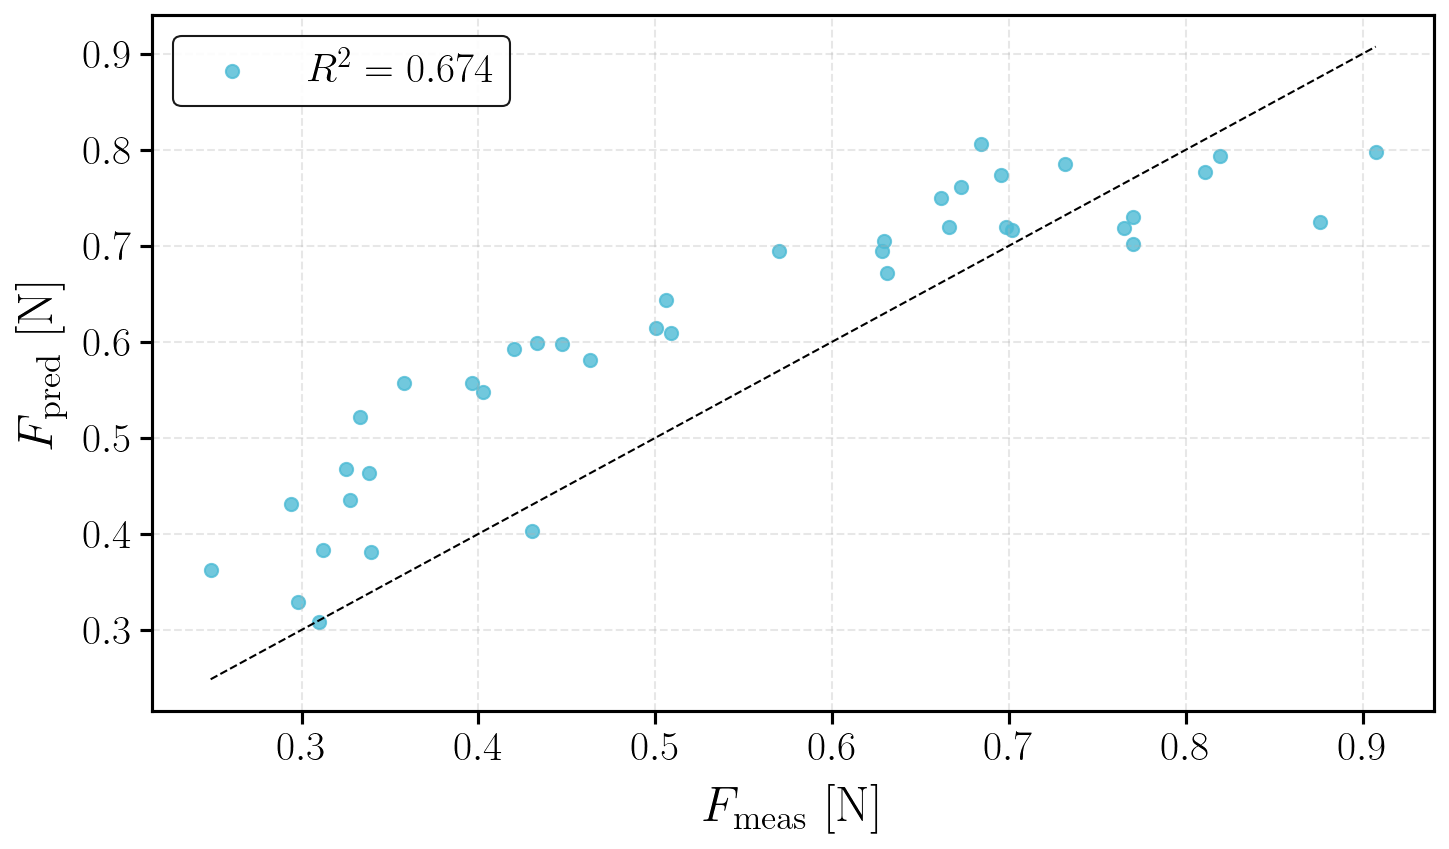

combined_space — measured vs predicted normal force (scatter, R² = 0.556)


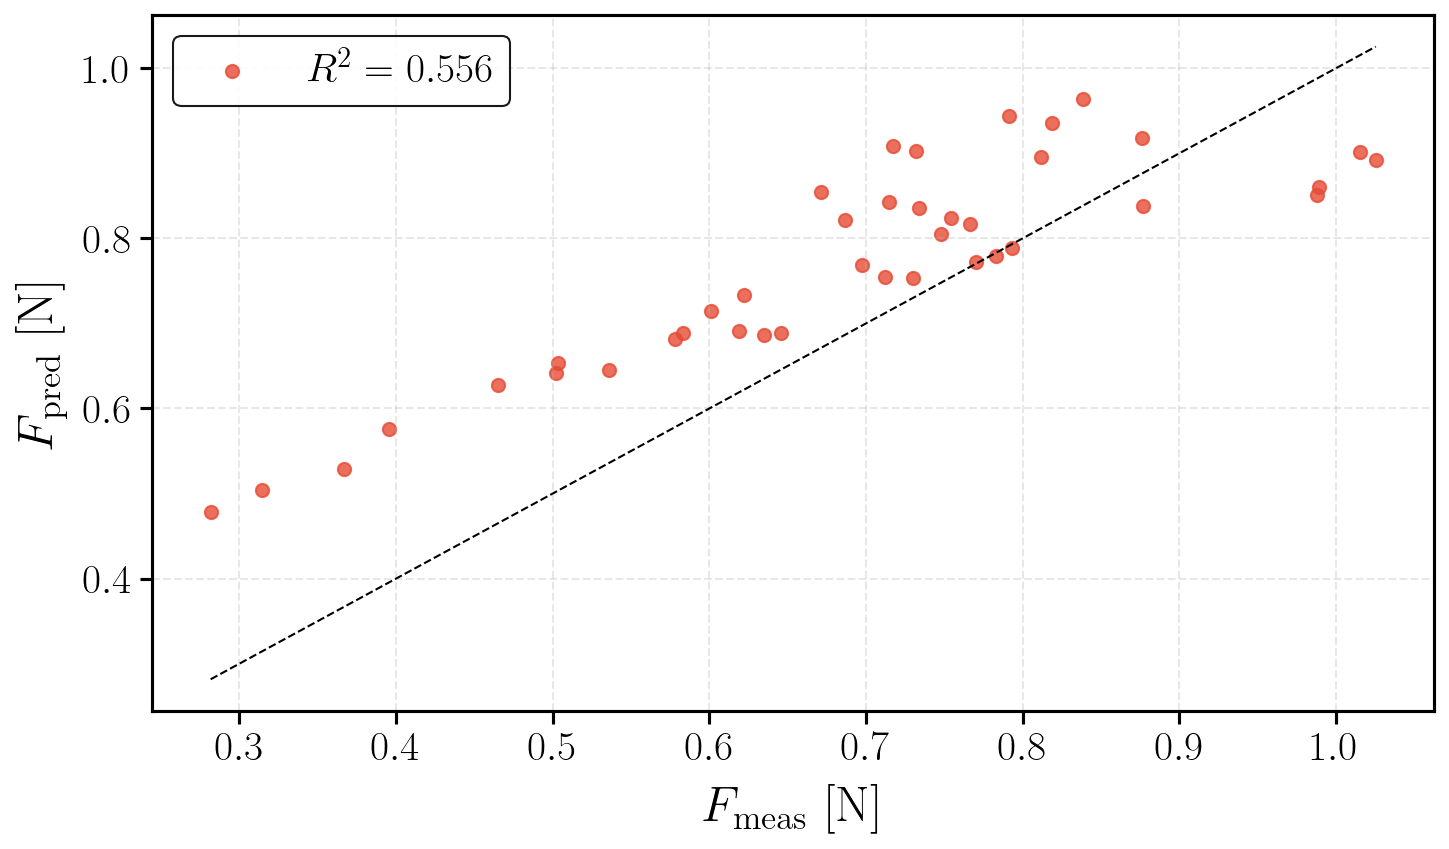

In [2]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

cfg_styles = [
    ('task_space',     COLORS[0]),
    ('combined_space', COLORS[1]),
]

for cfg, color in cfg_styles:
    d = df_all[df_all['Config'] == cfg]
    if len(d) == 0:
        print(f'{cfg}: no data')
        continue

    y  = d['Force_Normal_Mean_N'].values
    yp = d['Force_Pred_Mean_N'].values
    sst = np.sum((y - np.mean(y)) ** 2)
    r2  = float(1 - np.sum((y - yp) ** 2) / sst) if sst > 0 else np.nan

    print(f'{cfg} — measured vs predicted normal force (scatter, R² = {r2:.3f})')
    fig, ax = plt.subplots()
    ax.scatter(y, yp, s=40, alpha=0.8, color=color,
               label=rf'$R^2 = {r2:.3f}$')
    lims = [min(y.min(), yp.min()), max(y.max(), yp.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel(r'$F_{\mathrm{meas}}$ [N]')
    ax.set_ylabel(r'$F_{\mathrm{pred}}$ [N]')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'scatter_{cfg}.pdf'))
    plt.show()

## Per-sample prediction (error bars, colored by $K_{\mathrm{task}}$)

Both configs — per-sample measured vs predicted (colored by K_task, error bars = std)


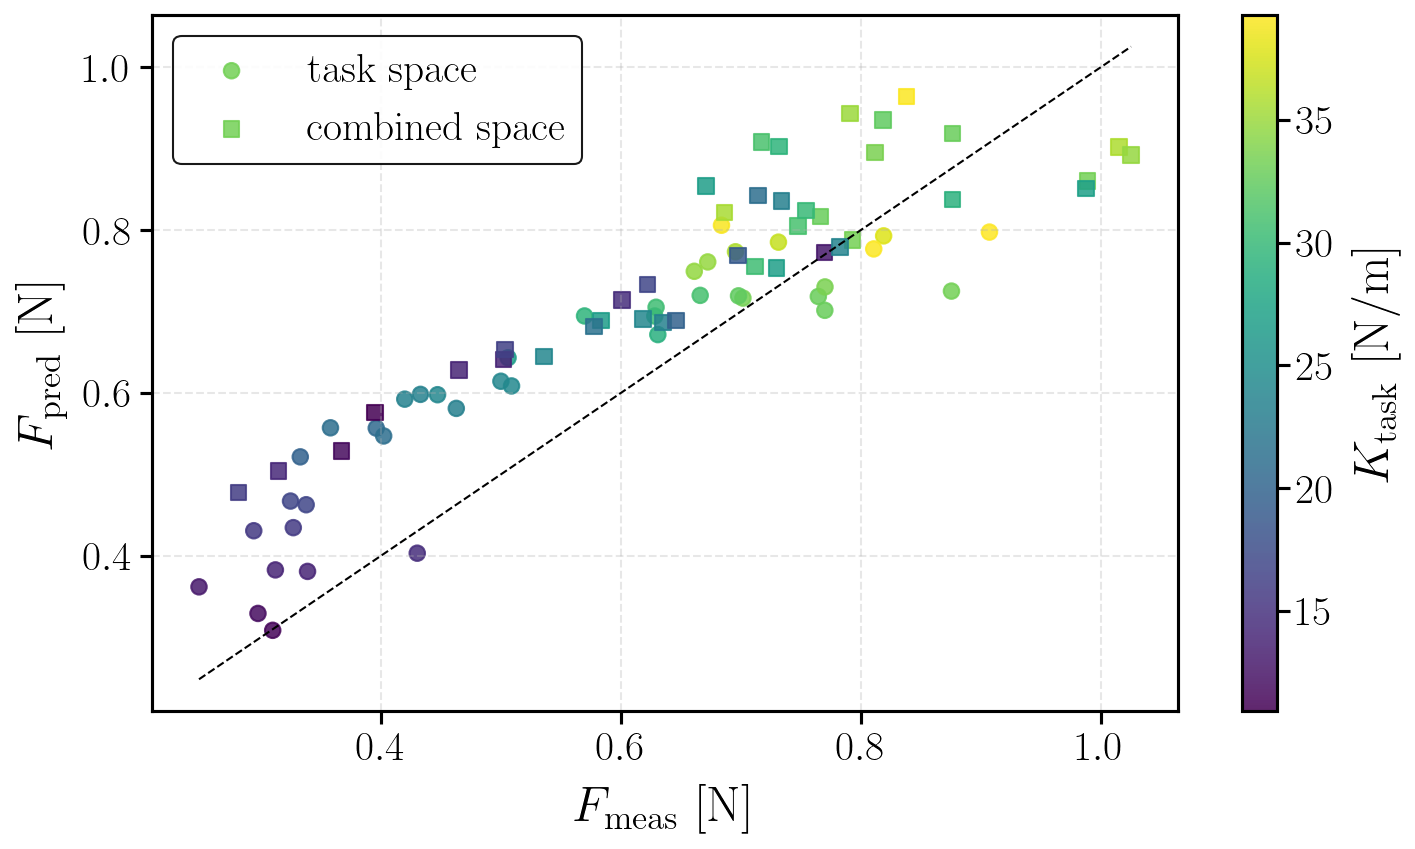

In [3]:
print('Both configs — per-sample measured vs predicted (colored by K_task, error bars = std)')

cfg_markers = [('task_space', 'o'), ('combined_space', 's')]

fig, ax = plt.subplots()
kw = dict(cmap='viridis',
          vmin=df_all['K_task_Npm'].min(),
          vmax=df_all['K_task_Npm'].max())

sc = None
for cfg, marker in cfg_markers:
    d = df_all[df_all['Config'] == cfg]
    if len(d) == 0:
        continue
    sc = ax.scatter(d['Force_Normal_Mean_N'], d['Force_Pred_Mean_N'],
                    c=d['K_task_Npm'], marker=marker, s=55, alpha=0.85,
                    label=cfg.replace('_', ' '), **kw)

lims = [df_all['Force_Normal_Mean_N'].min(), df_all['Force_Normal_Mean_N'].max()]
ax.plot(lims, lims, 'k--', lw=1)
if sc is not None:
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(r'$K_{\mathrm{task}}$ [N/m]')
ax.set_xlabel(r'$F_{\mathrm{meas}}$ [N]')
ax.set_ylabel(r'$F_{\mathrm{pred}}$ [N]')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_per_sample.pdf'))
plt.show()